<a href="https://colab.research.google.com/github/DeepanshuSharma1607/langgraph/blob/main/langgraph_tool_calling_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
!pip install tavily
!pip install langchain-mistralai

In [89]:
from langchain_mistralai import ChatMistralAI
from langchain_core.messages import (
    AIMessage,
    HumanMessage,
    SystemMessage,
    ToolMessage
)
from langgraph.graph import StateGraph , MessagesState , START , END , add_messages
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
import requests
from langchain.tools import tool
from tavily import TavilyClient
import os
from typing import Annotated , TypedDict
from langgraph.prebuilt import ToolNode , tools_condition


In [106]:
TAVILY_API_KEY = "put your api here"
OPENAPI_WEATHER_API_KEY = "put your api here"
CHAT_MISTRAL_API_KEY = "put your api here"

In [91]:
llm = ChatMistralAI(
    model="mistral-small-2506",
    api_key= CHAT_MISTRAL_API_KEY
)

In [92]:
@tool
def get_weather(city : str)->str:
  """Get weather of the city """
  url = f"http://api.openweathermap.org/data/2.5/weather?q={city}&appid={OPENAPI_WEATHER_API_KEY}&units=metric"

  response = requests.get(url)
  data = response.json()

  if str(data.get("cod")) !="200":
      return f"ERROR  :{data.get('message','Could not fetch weather')}"

  temp  = data["main"]["temp"]
  desc = data['weather'][0]['description']
  return f"weather in {city} : {desc} , {temp} degree celcius"

In [93]:
tavily_client = TavilyClient(api_key = TAVILY_API_KEY)
@tool
def get_news(city : str) ->str:
    """Get latest news about the city"""

    response = tavily_client.search(
        query = f"latest news in {city}",
        search_depth = "basic",
        max_results = 3
    )

    results = response.get("results",[])

    if not results:
        return f"No news found for {city}"

    news_list = []

    for r in results:
        title = r.get("title" , "No title")
        url = r.get("url","")
        snippet = r.get("content","")

        news_list.append(
        f"Title: {title}\nURL: {url}\nSnippet: {snippet[:100]}..."
        )

    return f"Latest News in {city}:\n\n" + "\n\n".join(news_list)

In [94]:
llm_with_tools = llm.bind_tools([get_weather , get_news])
tools={
    "get_weather" : get_weather,
    "get_news" : get_news
}

In [95]:
class MessagesState(TypedDict):
    messages: Annotated[list, add_messages]

In [96]:
SYSTEM_PROMPT = SystemMessage(content="""You are a helpful assistant with access to two tools:
- get_weather: fetches current weather for a city
- news search tool: fetches latest news

Rules:
1. Use a tool ONLY when the user's request genuinely needs live/current data (weather, latest news). Don't call a tool for general knowledge questions.
2. When you get tool results back, present them in a clean, well-formatted, readable way (use markdown, bullet points, or tables where helpful — not a raw dump).
3. If a tool call is denied by the user, politely tell them you couldn't fetch the live data and offer to help another way.
4. Keep responses concise and directly useful.
""")

In [97]:
def tool(state : MessagesState):
  if state['messages'][-1].tool_calls:
    last_message = state['messages'][-1]

    tool_messages = []
    denied = False

    for tool_call in last_message.tool_calls:
        tool_name = tool_call['name']
        confirm = input(f"Agent wants to call {tool_name} with {tool_call['args']}. Approve (y/n): ")

        if confirm.lower() == "n":
            denied = True
            tool_messages.append(ToolMessage(
                content="Tool call denied by user.",
                tool_call_id=tool_call['id']
            ))
            continue

        tool_result = tools[tool_name].invoke(tool_call)

        tool_messages.append(tool_result)

  return  {"messages":tool_messages}


In [98]:
def chatbot(state: MessagesState):
    messages = state['messages']
    result = llm_with_tools.invoke([SYSTEM_PROMPT] + messages)
    print("BOT :", result.content)
    return {"messages": [result]}


In [99]:
def human(state : MessagesState):
    message = input("Ask your question...\n")
    return {"messages":[HumanMessage(content=message)]}

In [100]:
def human_approval(state : MessagesState):
  if state["messages"][-1].content.lower() == "exit":
    return END
  return "chatbot"

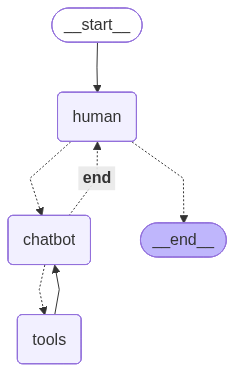

In [103]:
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display , Image
builder   = StateGraph(MessagesState)
builder.add_node("chatbot",chatbot)
builder.add_node("human",human)
builder.add_node("tools",tool)

builder.add_edge(START,"human")
builder.add_conditional_edges(
    "human",
    human_approval,
    {
        "chatbot": "chatbot",
        END: END,
    },
)
builder.add_conditional_edges(
    "chatbot",
    tools_condition,
    {
        "tools": "tools",
        END: "human",
    },
)
builder.add_edge("tools","chatbot")

memory = MemorySaver()
graph = builder.compile(checkpointer = memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [104]:
config = {"configurable": {"thread_id": "2"}, "recursion_limit": 100}
output = graph.invoke({"messages": []}, config=config)
print("\n--- Full Conversation ---\n")
for m in output["messages"]:
    print(f"{m.type.upper()}: {m.content}\n")

Ask your question...
hello


BOT : Hi! How can I assist you today?

Ask your question...
weather in palampur


BOT :

Agent wants to call get_weather with {'city': 'palampur'}. Approve (y/n): y


...

TOOL: weather in kullu : scattered clouds , 23.33 degree celcius

TOOL: Latest News in manali:

Title: Manali News Today - Instagram
URL: https://www.instagram.com/popular/manali-news-today?hl=en
Snippet: Manali has seen multiple incidents in recent weeks, including a fatal hit-and-run on June 1 where a ...

Title: Today Manali News - Instagram
URL: https://www.instagram.com/popular/today-manali-news?hl=en
Snippet: Manali was in the news after a 60-year-old pedestrian was killed on June 1 when a drunk Delhi touris...

Title: manali news - The Indian Express
URL: https://indianexpress.com/about/manali
Snippet: MANALI NEWS. Manali tourists, Rajasthan · Tourist group from Rajasthan fined in Manali for reckless ...

TOOL: No news found for kullu

AI: Here is the weather and news update for Manali and Kullu:

### Weather Updates:

- **Manali**: Overcast clouds with a temperature of 34.99°C.
- **Kullu**: Scattered clouds with a temperature of 23.33°C.

### News Updates:

- **Manali**:
  1. **Fatal Hit-and-Run**: Manali has recently experienced a fatal hit-and-run incident on June 1.
  2. **Tourist Incident**: A 60-year-old pedestrian was killed when a drunk tourist from Delhi hit him.
  3. **Reckless Tourists Fined**: A group of tourists from Rajasthan were fined in Manali for reckless behavior.

- **Kullu**: No significant news updates found.

HUMAN: exit

In [105]:
from rich import print
for m in output["messages"]:
    print(m)

HumanMessage(
    content='hello',
    additional_kwargs={},
    response_metadata={},
    id='6b2136a2-da86-4a4f-82ab-6bf053bc9a6c'
)

AIMessage(
    content='Hi! How can I assist you today?',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 267,
            'total_tokens': 277,
            'completion_tokens': 10,
            'prompt_tokens_details': {'cached_tokens': 0}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f27bc-b945-7432-b3ed-ed3d7864b179-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 267, 'output_tokens': 10, 'total_tokens': 277}
)

HumanMessage(
    content='weather in palampur',
    additional_kwargs={},
    response_metadata={},
    id='ec384aed-7f90-42bf-8cc5-ff73ce91d730'
)

AIMessage(
    content='',
    additional_kwargs={
        'tool_calls': [
            {
                'id': '1txeQwS2o',
                'type': 'function',
                'function': {'name': 'get_weather', 'arguments': '{"city": "palampur"}'},
                'index': 0
            }
        ]
    },
    response_metadata={
        'token_usage': {
            'prompt_tokens': 284,
            'total_tokens': 298,
            'completion_tokens': 14,
            'prompt_tokens_details': {'cached_tokens': 128}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'tool_calls',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f27bc-d2ac-7461-a5bf-e748af79bff5-0',
    tool_calls=[{'name': 'get_weather', 'args': {'city': 'palampur'}, 'id': '1txeQwS2o', 'type': 'tool_call'}],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 284, 'output_tokens': 14, 'total_tokens': 298}
)

ToolMessage(
    content='weather in palampur : scattered clouds , 30.75 degree celcius',
    name='get_weather',
    id='7f218d57-77ef-449a-aaaa-691ea7ba26ea',
    tool_call_id='1txeQwS2o'
)

...

ToolMessage(
    content='weather in kullu : scattered clouds , 23.33 degree celcius',
    name='get_weather',
    id='081a1659-88f0-4361-a4c7-e480811a193e',
    tool_call_id='SFoExXeVV'
)

ToolMessage(
    content='Latest News in manali:\n\nTitle: Manali News Today - Instagram\nURL: 
https://www.instagram.com/popular/manali-news-today?hl=en\nSnippet: Manali has seen multiple incidents in recent 
weeks, including a fatal hit-and-run on June 1 where a ...\n\nTitle: Today Manali News - Instagram\nURL: 
https://www.instagram.com/popular/today-manali-news?hl=en\nSnippet: Manali was in the news after a 60-year-old 
pedestrian was killed on June 1 when a drunk Delhi touris...\n\nTitle: manali news - The Indian Express\nURL: 
https://indianexpress.com/about/manali\nSnippet: MANALI NEWS. Manali tourists, Rajasthan · Tourist group from 
Rajasthan fined in Manali for reckless ...',
    name='get_news',
    id='6482b717-9e8d-4a37-b565-5a8ade41af62',
    tool_call_id='SxPQg4jmm'
)

ToolMessage(
    content='No news found for kullu',
    name='get_news',
    id='c2371eb0-cca1-4807-a096-fae1e5442369',
    tool_call_id='bzZ3ELxEZ'
)

AIMessage(
    content='Here is the weather and news update for Manali and Kullu:\n\n### Weather Updates:\n\n- **Manali**: 
Overcast clouds with a temperature of 34.99°C.\n- **Kullu**: Scattered clouds with a temperature of 23.33°C.\n\n###
News Updates:\n\n- **Manali**:\n  1. **Fatal Hit-and-Run**: Manali has recently experienced a fatal hit-and-run 
incident on June 1.\n  2. **Tourist Incident**: A 60-year-old pedestrian was killed when a drunk tourist from Delhi
hit him.\n  3. **Reckless Tourists Fined**: A group of tourists from Rajasthan were fined in Manali for reckless 
behavior.\n\n- **Kullu**: No significant news updates found.',
    additional_kwargs={},
    response_metadata={
        'token_usage': {
            'prompt_tokens': 1171,
            'total_tokens': 1339,
            'completion_tokens': 168,
            'prompt_tokens_details': {'cached_tokens': 768}
        },
        'model_name': 'mistral-small-2506',
        'model': 'mistral-small-2506',
        'finish_reason': 'stop',
        'model_provider': 'mistralai'
    },
    id='lc_run--019f27bd-96b1-7ab3-a328-3fdfe39202c0-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={'input_tokens': 1171, 'output_tokens': 168, 'total_tokens': 1339}
)

HumanMessage(content='exit', additional_kwargs={}, response_metadata={}, id='0d2c6756-6405-4d2f-96aa-361319929410')